# 06 - Dashboard Interactivo con Plotly

**Pregunta de negocio:** ¿Podemos dar a stakeholders exploración interactiva?

## Objetivos
- Crear visualizaciones interactivas con hover, zoom, filtros
- Construir series temporales con range slider
- Entender cuándo usar estático (matplotlib) vs interactivo (plotly)

## Teoría
| Herramienta | Uso ideal |
|---|---|
| matplotlib/seaborn | Reportes, papers, imágenes estáticas de calidad |
| plotly | Exploración, dashboards, presentaciones interactivas |
| plotly express (px) | API rápida para gráficas comunes |
| plotly graph_objects (go) | Control total para gráficas complejas |

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data/raw")

In [2]:
merged = pd.read_csv(os.path.join(project_root, "data/processed/vehicle_survey_merged.csv"))
data = merged[merged['has_survey'] == True].copy() if 'has_survey' in merged.columns else merged.copy()

files = sorted(glob.glob(os.path.join(data_dir, "telemetry/telemetry_*.csv")))
tel_day1 = pd.read_csv(files[0], parse_dates=['timestamp'])
fleet = pd.read_csv(os.path.join(data_dir, "fleet_profiles.csv"))
tel_day1 = tel_day1.merge(fleet[['vehicle_id', 'vehicle_type']], on='vehicle_id', how='left')

print(f"Merged: {data.shape} | Telemetría día 1: {len(tel_day1):,}")

colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

Merged: (50, 35) | Telemetría día 1: 170,863


## 1. Scatter interactivo: Velocidad vs Consumo

Pasa el mouse sobre los puntos. Haz click en la leyenda para filtrar.

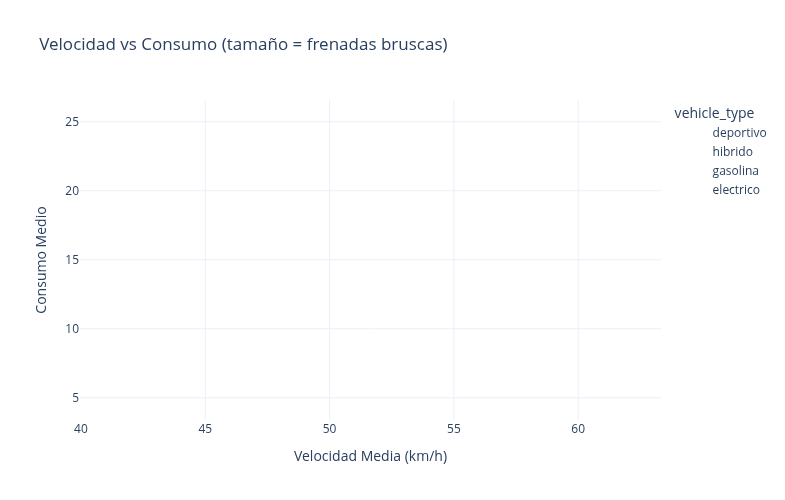

In [3]:
fig = px.scatter(
    data, x='speed_mean', y='consumption_mean', color='vehicle_type',
    size='harsh_braking_count',
    hover_data=['vehicle_id', 'n_viajes', 'estimated_km'],
    title='Velocidad vs Consumo (tamaño = frenadas bruscas)',
    labels={'speed_mean': 'Velocidad Media (km/h)', 'consumption_mean': 'Consumo Medio'},
    color_discrete_map=colors, template='plotly_white',
)
fig.update_layout(height=500)
fig.show()

## 2. Box plots con selector de variable

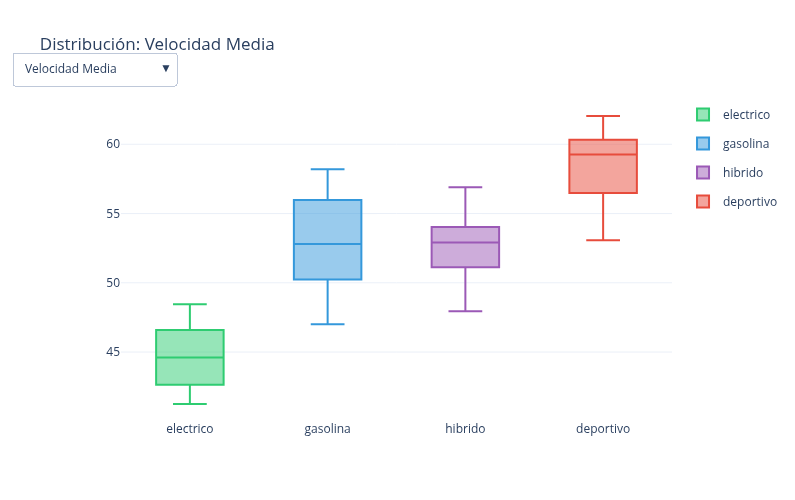

In [4]:
variables = ['speed_mean', 'consumption_mean', 'harsh_braking_count', 'speed_std']
var_labels = ['Velocidad Media', 'Consumo Medio', 'Frenadas Bruscas', 'Variabilidad Velocidad']

fig = go.Figure()
n_types = 4
type_list = ['electrico', 'gasolina', 'hibrido', 'deportivo']

for i, (var, label) in enumerate(zip(variables, var_labels)):
    for vtype in type_list:
        subset = data[data['vehicle_type'] == vtype]
        fig.add_trace(go.Box(
            y=subset[var], name=vtype, marker_color=colors[vtype],
            visible=(i == 0), legendgroup=vtype, showlegend=(i == 0),
        ))

buttons = []
for i, label in enumerate(var_labels):
    vis = [False] * (len(variables) * n_types)
    for j in range(n_types):
        vis[i * n_types + j] = True
    buttons.append(dict(label=label, method='update',
                        args=[{'visible': vis}, {'title': f'Distribución: {label}'}]))

fig.update_layout(
    title='Distribución: Velocidad Media', template='plotly_white', height=500,
    updatemenus=[dict(type='dropdown', x=0.1, y=1.15, buttons=buttons, showactive=True)],
)
fig.show()

## 3. Serie temporal con range slider

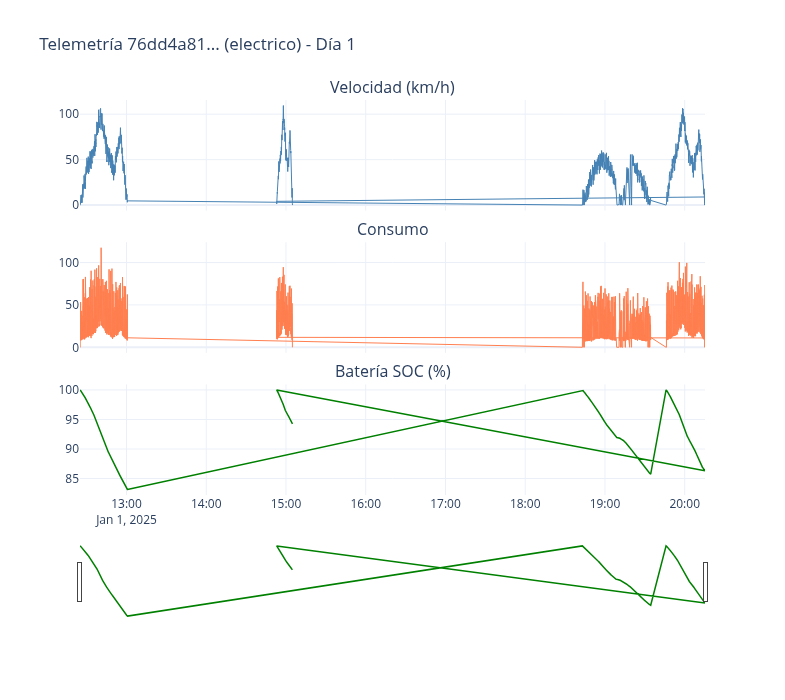

→ Arrastra el slider inferior para hacer zoom en un rango de tiempo


In [5]:
sample_vid = tel_day1['vehicle_id'].unique()[0]
v_data = tel_day1[tel_day1['vehicle_id'] == sample_vid]
vtype = v_data['vehicle_type'].iloc[0]

fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                    subplot_titles=('Velocidad (km/h)', 'Consumo', 'Batería SOC (%)'),
                    vertical_spacing=0.08)

fig.add_trace(go.Scatter(x=v_data['timestamp'], y=v_data['speed_kmh'],
                         mode='lines', name='Velocidad', line=dict(color='steelblue', width=1)), row=1, col=1)
fig.add_trace(go.Scatter(x=v_data['timestamp'], y=v_data['fuel_consumption_rate'],
                         mode='lines', name='Consumo', line=dict(color='coral', width=1)), row=2, col=1)
fig.add_trace(go.Scatter(x=v_data['timestamp'], y=v_data['battery_soc_pct'],
                         mode='lines', name='SOC', line=dict(color='green', width=1.5)), row=3, col=1)

fig.update_layout(
    title=f'Telemetría {sample_vid[:8]}... ({vtype}) - Día 1',
    height=700, template='plotly_white', showlegend=False,
    xaxis3=dict(rangeslider=dict(visible=True), type='date'),
)
fig.show()

print("→ Arrastra el slider inferior para hacer zoom en un rango de tiempo")

## 4. Sunburst: Jerarquía tipo → estilo → satisfacción

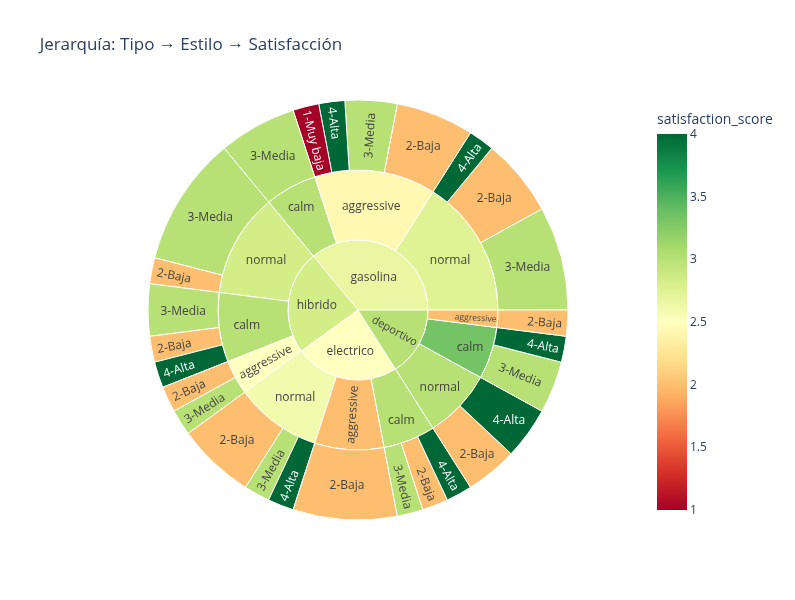

→ Click en un segmento para hacer zoom. Click en el centro para volver.


In [6]:
sun_data = data.dropna(subset=['driving_style', 'satisfaction_score']).copy()
sun_data['sat_label'] = sun_data['satisfaction_score'].map(
    {1: '1-Muy baja', 2: '2-Baja', 3: '3-Media', 4: '4-Alta', 5: '5-Muy alta'})

fig = px.sunburst(
    sun_data, path=['vehicle_type', 'driving_style', 'sat_label'],
    title='Jerarquía: Tipo → Estilo → Satisfacción',
    color='satisfaction_score', color_continuous_scale='RdYlGn', template='plotly_white',
)
fig.update_layout(height=600)
fig.show()

print("→ Click en un segmento para hacer zoom. Click en el centro para volver.")

## 5. Satisfacción por segmento demográfico

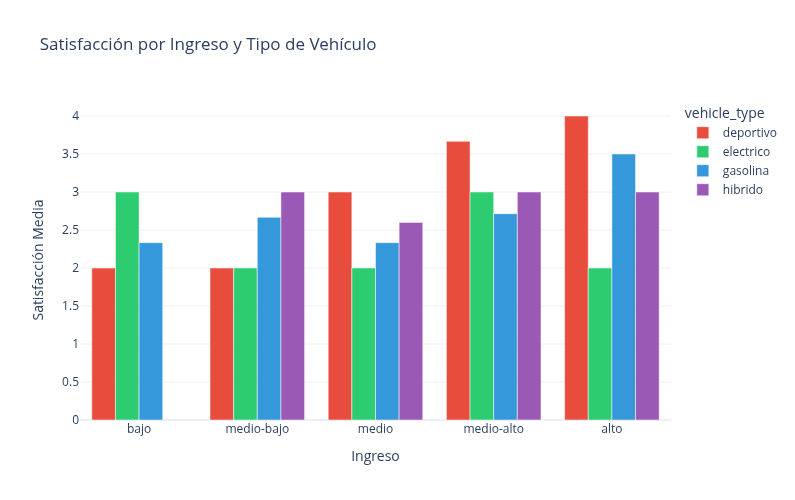

In [7]:
if 'income_bracket' in data.columns:
    income_order = ['bajo', 'medio-bajo', 'medio', 'medio-alto', 'alto']
    sat_data = data.groupby(['income_bracket', 'vehicle_type'])['satisfaction_score'].mean().reset_index()

    fig = px.bar(
        sat_data, x='income_bracket', y='satisfaction_score', color='vehicle_type',
        barmode='group', title='Satisfacción por Ingreso y Tipo de Vehículo',
        labels={'income_bracket': 'Ingreso', 'satisfaction_score': 'Satisfacción Media'},
        color_discrete_map=colors, template='plotly_white',
        category_orders={'income_bracket': income_order},
    )
    fig.update_layout(height=500)
    fig.show()

## 6. Mapa GPS interactivo

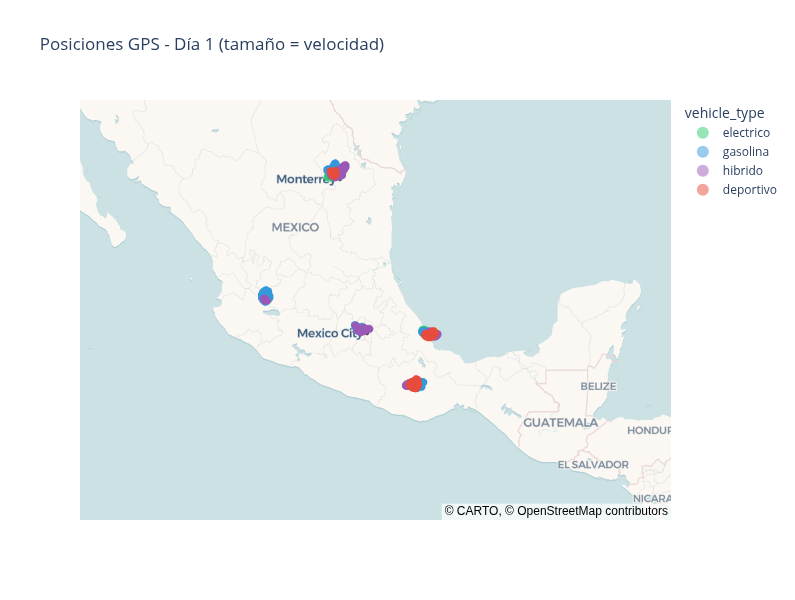

In [8]:
gps = tel_day1.iloc[::20][['gps_lat', 'gps_lon', 'speed_kmh', 'vehicle_type', 'road_type']].dropna()

fig = px.scatter_map(
    gps, lat='gps_lat', lon='gps_lon', color='vehicle_type',
    size='speed_kmh', size_max=8,
    hover_data=['road_type', 'speed_kmh'],
    title='Posiciones GPS - Día 1 (tamaño = velocidad)',
    color_discrete_map=colors, template='plotly_white', zoom=4, opacity=0.5,
)
fig.update_layout(height=600)
fig.show()

## Resumen

> **¿Podemos dar a stakeholders exploración interactiva?**
>
> Sí. Con plotly: hover para detalles, click para filtrar, slider para rangos temporales.
> Para un dashboard de producción, el siguiente paso sería Dash o Streamlit.

### Entregable Fase 2:
- EDA completo con hallazgos visuales
- Gráficas estáticas (matplotlib/seaborn) + interactivas (plotly) + mapas (folium)

### Siguiente fase:
→ **Fase 3**: Estadística Inferencial y Pruebas de Hipótesis